In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datasets principales
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('data/olist_order_payments_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

print("Datasets cargados:")
print(f"  orders:        {orders.shape}")
print(f"  order_items:   {order_items.shape}")
print(f"  payments:      {order_payments.shape}")
print(f"  customers:     {customers.shape}")
print(f"  products:      {products.shape}")

Datasets cargados:
  orders:        (99441, 8)
  order_items:   (112650, 7)
  payments:      (103886, 5)
  customers:     (99441, 5)
  products:      (32951, 9)


In [4]:
# Convertir fechas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Ver rango de fechas
print(f"Período: {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")

# Ver estados de órdenes
print(f"\nEstados de órdenes:")
print(orders['order_status'].value_counts())

Período: 2016-09-04 → 2018-10-17

Estados de órdenes:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [5]:
# Unir orders + order_items + payments
df = orders[orders['order_status'] == 'delivered'].copy()

df = df.merge(order_items[['order_id', 'product_id', 'price', 'freight_value']], on='order_id')
df = df.merge(order_payments[['order_id', 'payment_value']], on='order_id')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')
df = df.merge(category_translation, on='product_category_name', how='left')

# Columnas de tiempo
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

print(f"Registros para análisis: {df.shape}")
print(f"\nPrimeras columnas disponibles:")
print(df.columns.tolist())

Registros para análisis: (115035, 17)

Primeras columnas disponibles:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'product_id', 'price', 'freight_value', 'payment_value', 'product_category_name', 'product_category_name_english', 'year', 'month', 'year_month']


In [6]:
# Métricas generales
total_revenue = df['payment_value'].sum()
total_orders = df['order_id'].nunique()
total_items = len(df)
avg_order_value = total_revenue / total_orders

print("=" * 40)
print("  MÉTRICAS GENERALES")
print("=" * 40)
print(f"  Revenue total:       R$ {total_revenue:,.2f}")
print(f"  Órdenes únicas:      {total_orders:,}")
print(f"  Items vendidos:      {total_items:,}")
print(f"  Ticket promedio:     R$ {avg_order_value:.2f}")
print("=" * 40)

  MÉTRICAS GENERALES
  Revenue total:       R$ 19,776,160.44
  Órdenes únicas:      96,477
  Items vendidos:      115,035
  Ticket promedio:     R$ 204.98


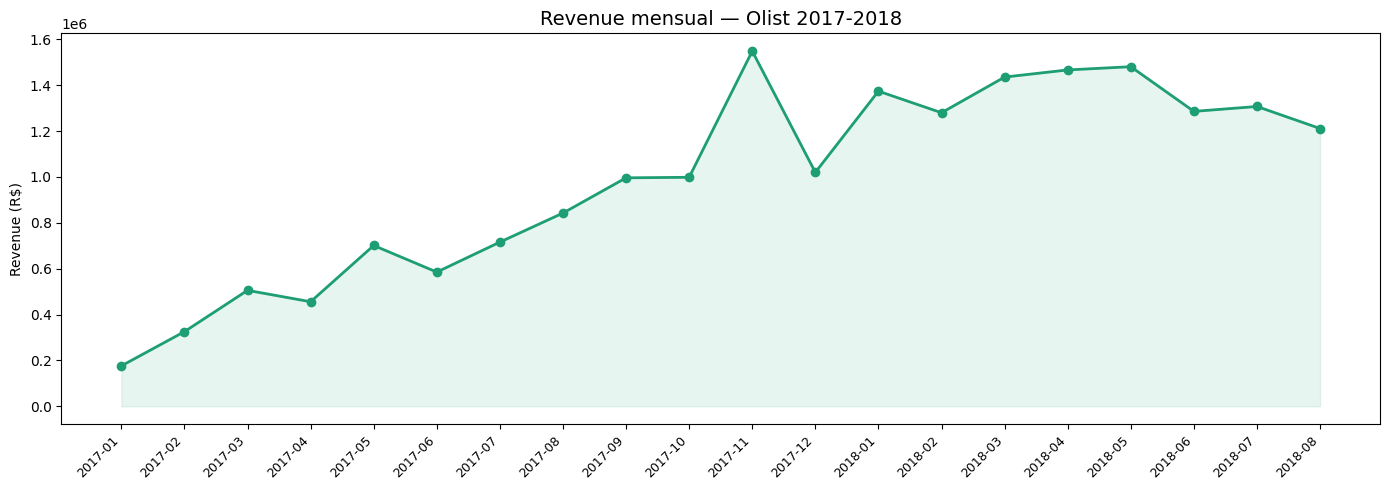

Gráfica guardada como monthly_revenue.png


In [7]:
# Ventas mensuales
monthly_revenue = df.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)

# Filtrar 2016 incompleto (solo tiene Sep-Dic)
monthly_revenue = monthly_revenue[monthly_revenue['year_month'].astype(str) >= '2017-01']

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['year_month_str'], monthly_revenue['payment_value'], 
         marker='o', linewidth=2, color='#1D9E75')
plt.fill_between(monthly_revenue['year_month_str'], monthly_revenue['payment_value'], 
                 alpha=0.1, color='#1D9E75')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Revenue mensual — Olist 2017-2018', fontsize=14)
plt.ylabel('Revenue (R$)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print("Gráfica guardada como monthly_revenue.png")

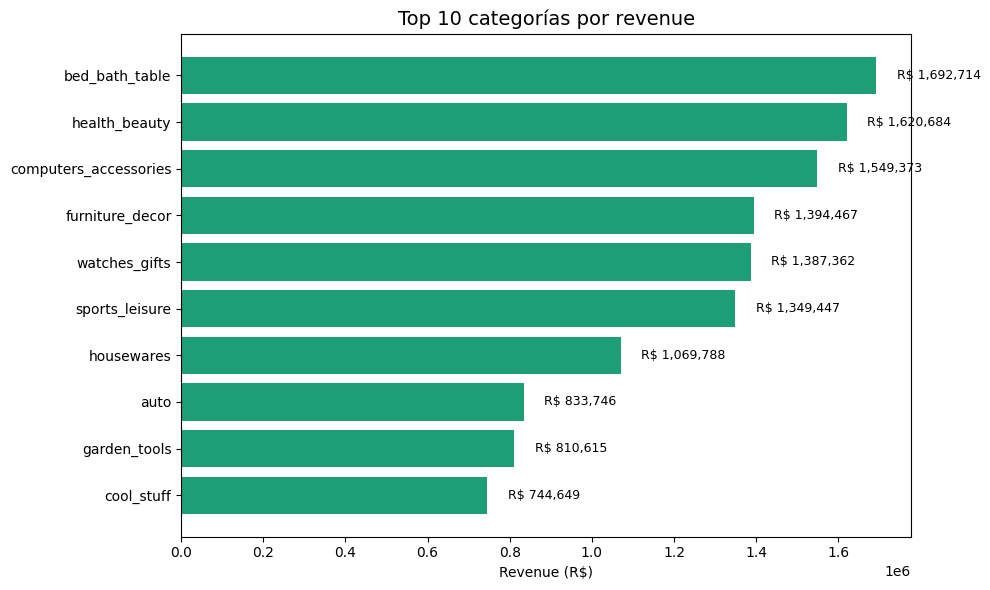

In [8]:
# Top 10 categorías por revenue
top_categories = (df.groupby('product_category_name_english')['payment_value']
                  .sum()
                  .sort_values(ascending=True)
                  .tail(10))

plt.figure(figsize=(10, 6))
bars = plt.barh(top_categories.index, top_categories.values, color='#1D9E75')
plt.xlabel('Revenue (R$)')
plt.title('Top 10 categorías por revenue', fontsize=14)

# Agregar valores al final de cada barra
for bar, value in zip(bars, top_categories.values):
    plt.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
             f'R$ {value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()

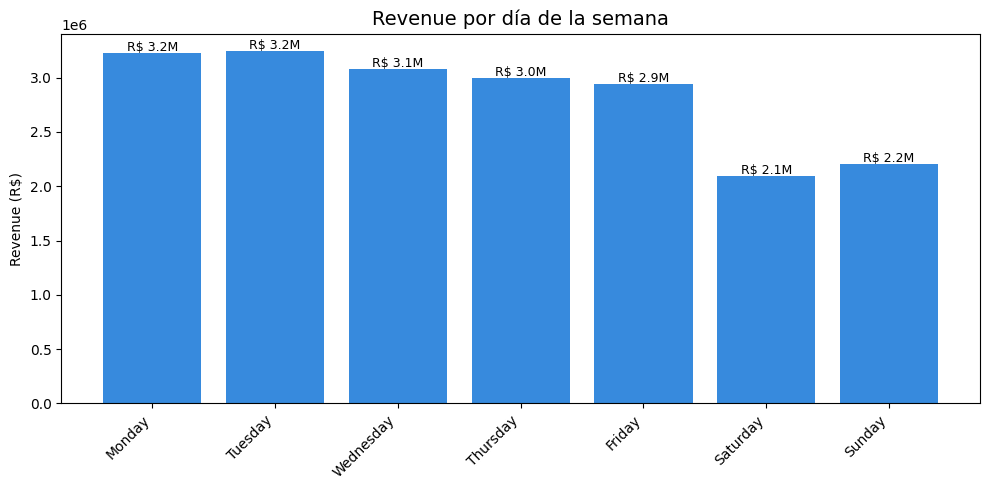

In [9]:
# Ventas por día de la semana
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_revenue = (df.groupby('day_of_week')['payment_value']
               .sum()
               .reindex(day_order))

plt.figure(figsize=(10, 5))
bars = plt.bar(day_revenue.index, day_revenue.values, color='#378ADD')
plt.title('Revenue por día de la semana', fontsize=14)
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')

for bar, value in zip(bars, day_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'R$ {value/1e6:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('revenue_by_day.png', dpi=150)
plt.show()

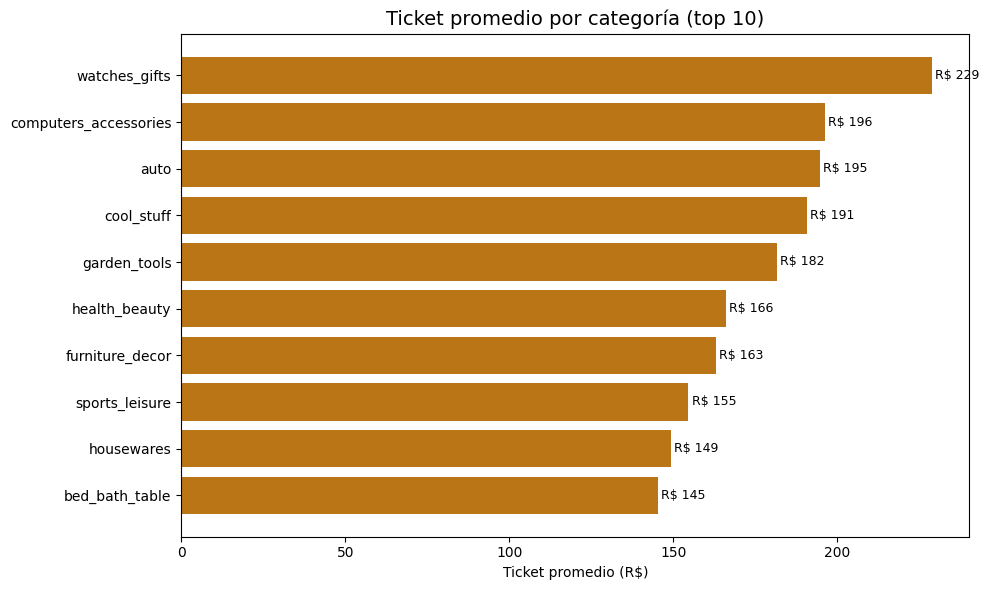

In [10]:
# Ticket promedio por categoría (top 10)
top_cat_names = top_categories.index.tolist()

avg_ticket = (df[df['product_category_name_english'].isin(top_cat_names)]
              .groupby('product_category_name_english')['payment_value']
              .mean()
              .sort_values(ascending=True))

plt.figure(figsize=(10, 6))
bars = plt.barh(avg_ticket.index, avg_ticket.values, color='#BA7517')
plt.xlabel('Ticket promedio (R$)')
plt.title('Ticket promedio por categoría (top 10)', fontsize=14)

for bar, value in zip(bars, avg_ticket.values):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'R$ {value:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('avg_ticket_by_category.png', dpi=150)
plt.show()

In [11]:
# Resumen de hallazgos
print("=" * 50)
print("  HALLAZGOS PRINCIPALES — OLIST SALES DASHBOARD")
print("=" * 50)
print(f"""
1. CRECIMIENTO: Revenue creció consistentemente
   de 2017 a 2018, indicando expansión del negocio.

2. CATEGORÍAS TOP: bed_bath_table y health_beauty
   lideran en revenue total por volumen de ventas.

3. COMPORTAMIENTO DE COMPRA: Los clientes compran
   principalmente de lunes a jueves. El fin de semana
   las ventas caen significativamente.

4. TICKET PROMEDIO: watches_gifts y computers_accessories
   tienen el ticket más alto (R$ {avg_ticket['watches_gifts']:.0f} y 
   R$ {avg_ticket['computers_accessories']:.0f} respectivamente).

5. ESCALA: 96,477 órdenes entregadas con revenue
   total de R$ {total_revenue:,.0f} en el período.
""")

  HALLAZGOS PRINCIPALES — OLIST SALES DASHBOARD

1. CRECIMIENTO: Revenue creció consistentemente
   de 2017 a 2018, indicando expansión del negocio.

2. CATEGORÍAS TOP: bed_bath_table y health_beauty
   lideran en revenue total por volumen de ventas.

3. COMPORTAMIENTO DE COMPRA: Los clientes compran
   principalmente de lunes a jueves. El fin de semana
   las ventas caen significativamente.

4. TICKET PROMEDIO: watches_gifts y computers_accessories
   tienen el ticket más alto (R$ 229 y 
   R$ 196 respectivamente).

5. ESCALA: 96,477 órdenes entregadas con revenue
   total de R$ 19,776,160 en el período.

